# Deep Learning for IoT Data Analysis
## Human Activity Recognition with a 1D Convolutional Neural Network

**Dataset:** UCI HAR (Human Activity Recognition Using Smartphones)
**Model:** 1D-CNN on raw inertial sensor signals
**Task:** 6-class classification (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING)

This notebook implements the full pipeline required by the project brief:
1. Dataset selection & download
2. Data preprocessing (cleaning, normalization, encoding, train/test split)
3. Deep learning model implementation (1D-CNN) with justification
4. Training visualization (loss & accuracy curves)
5. Model evaluation (accuracy, precision, F1-score, confusion matrix, ROC curve)


## 1. Setup and Imports

In [1]:
# Core scientific stack
import os, io, zipfile, urllib.request, ssl, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, roc_curve, auc)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization,
                                     MaxPooling1D, GlobalAveragePooling1D,
                                     Dense, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))
sns.set_style("whitegrid")


TensorFlow: 2.19.0
GPU available: True


## 2. Dataset Description and Download

### 2.1 About UCI HAR

The **UCI Human Activity Recognition (HAR) Using Smartphones** dataset was collected from 30 volunteers aged 19–48 who wore a Samsung Galaxy S II smartphone on the waist while performing six activities of daily living. The phone's embedded IMU sampled at **50 Hz**, producing 3-axis **accelerometer** and 3-axis **gyroscope** readings. The signals were then split into fixed-length windows of 2.56 seconds (128 samples) with 50% overlap.

- **Source:** UCI Machine Learning Repository — https://archive.ics.uci.edu/ml/datasets/human+activity+recognition+using+smartphones
- **Samples:** 10,299 total (7,352 train / 2,947 test), split by subject
- **Features (raw):** 9 channels × 128 time-steps per window (body_acc_{x,y,z}, body_gyro_{x,y,z}, total_acc_{x,y,z})
- **Target:** 6 activity classes

We use the **raw inertial signals** rather than the 561 pre-engineered features, because deep learning models are designed to learn features directly from raw data.


In [2]:
# Download UCI HAR dataset
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
DATA_DIR = "UCI HAR Dataset"

if not os.path.exists(DATA_DIR):
    print("Downloading UCI HAR Dataset (~60 MB)...")
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(URL, context=ctx, timeout=60) as r:
        with zipfile.ZipFile(io.BytesIO(r.read())) as z:
            z.extractall(".")
    print("Done.")
else:
    print("Dataset already present.")
!ls "UCI HAR Dataset"


Done.
activity_labels.txt  features_info.txt	features.txt  README.txt  test	train


In [3]:
# Load raw inertial signals (9 channels) and labels
ACTIVITIES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
              "SITTING", "STANDING", "LAYING"]
SIGNAL_NAMES = ["body_acc_x", "body_acc_y", "body_acc_z",
                "body_gyro_x", "body_gyro_y", "body_gyro_z",
                "total_acc_x", "total_acc_y", "total_acc_z"]

def load_signal(subset, signal):
    path = f"UCI HAR Dataset/{subset}/Inertial Signals/{signal}_{subset}.txt"
    return np.loadtxt(path)

def load_set(subset):
    X = np.stack([load_signal(subset, s) for s in SIGNAL_NAMES], axis=-1)   # (N, 128, 9)
    y = np.loadtxt(f"UCI HAR Dataset/{subset}/y_{subset}.txt").astype(int) - 1  # 0-indexed
    return X.astype(np.float32), y

X_train_full, y_train_full = load_set("train")
X_test, y_test = load_set("test")

print(f"Train shape: {X_train_full.shape}, labels: {y_train_full.shape}")
print(f"Test  shape: {X_test.shape}, labels: {y_test.shape}")
print("Class distribution (train):")
for i, name in enumerate(ACTIVITIES):
    print(f"  {i} {name:<22s} {np.sum(y_train_full==i)}")


Train shape: (7352, 128, 9), labels: (7352,)
Test  shape: (2947, 128, 9), labels: (2947,)
Class distribution (train):
  0 WALKING                1226
  1 WALKING_UPSTAIRS       1073
  2 WALKING_DOWNSTAIRS     986
  3 SITTING                1286
  4 STANDING               1374
  5 LAYING                 1407


### 2.2 Quick exploration — a sample window per activity

To sanity-check the data, we plot one body-acceleration window per class. Cyclical activities (walking) show clear periodic patterns; static postures (sitting, standing, laying) show very low variance with gravity aligned to a different axis. These distinct signatures are exactly what a convolutional model should be able to learn.


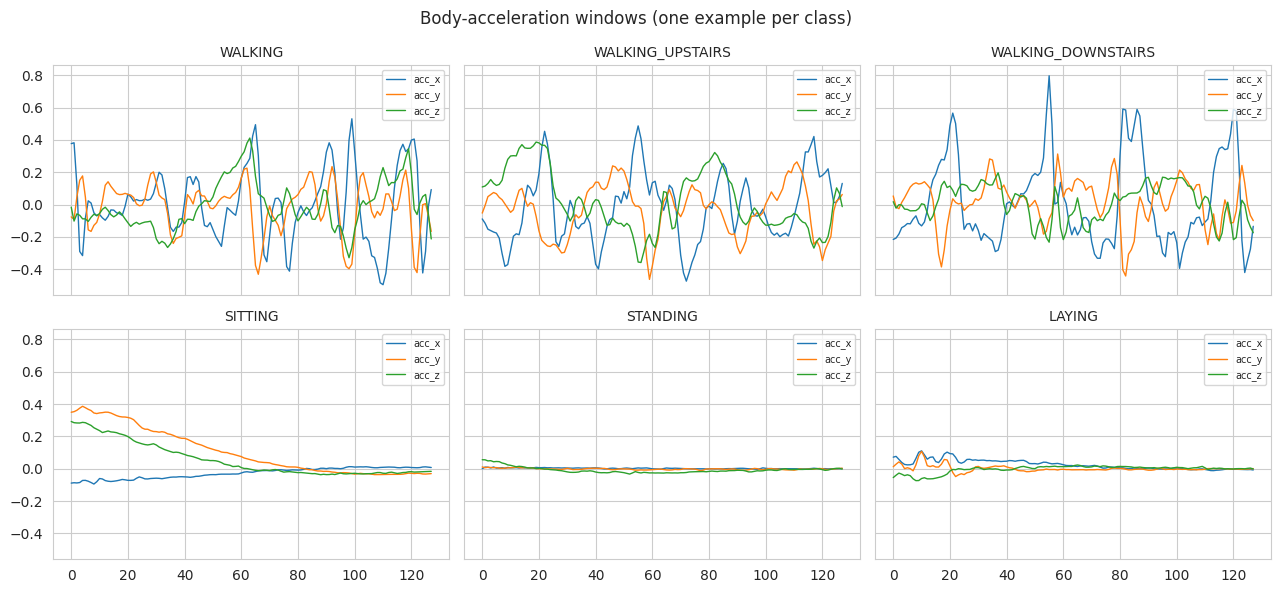

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True, sharey=True)
axes = axes.ravel()
for i, name in enumerate(ACTIVITIES):
    idx = np.where(y_train_full == i)[0][0]
    for c, lbl in zip(range(3), ["acc_x", "acc_y", "acc_z"]):
        axes[i].plot(X_train_full[idx, :, c], label=lbl, lw=1)
    axes[i].set_title(name, fontsize=10)
    axes[i].legend(fontsize=7, loc="upper right")
fig.suptitle("Body-acceleration windows (one example per class)")
plt.tight_layout()
plt.savefig("sample_signals.png", dpi=140, bbox_inches="tight")
plt.show()


## 3. Data Preprocessing

**Steps:**
1. **Missing values:** UCI HAR's raw inertial signals are provided pre-cleaned — we verify there are no NaNs.
2. **Train/validation split:** We carve 15% off the training set (stratified) for validation during training. The official test set is held out entirely for final evaluation.
3. **Normalization:** Per-channel standardization (zero mean, unit variance) using statistics computed on the training data **only** — preventing leakage from validation/test.
4. **Label encoding:** Labels are integers 0–5; we use `sparse_categorical_crossentropy`, which accepts these directly without one-hot encoding.


In [5]:
# Sanity check for missing values
print("NaNs in X_train_full:", np.isnan(X_train_full).sum())
print("NaNs in X_test     :", np.isnan(X_test).sum())

# Train / validation split (stratified)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15, stratify=y_train_full, random_state=SEED)
print("X_tr :", X_tr.shape,  "X_val:", X_val.shape, "X_test:", X_test.shape)

# Per-channel standardization — fit on TRAIN only
N_CHANNELS = X_tr.shape[-1]
scaler = StandardScaler()
scaler.fit(X_tr.reshape(-1, N_CHANNELS))

def apply_scaler(X):
    shape = X.shape
    return scaler.transform(X.reshape(-1, N_CHANNELS)).reshape(shape).astype(np.float32)

X_tr  = apply_scaler(X_tr)
X_val = apply_scaler(X_val)
X_test_s = apply_scaler(X_test)
print("After scaling — mean ≈ 0, std ≈ 1:",
      X_tr.mean().round(3), X_tr.std().round(3))


NaNs in X_train_full: 0
NaNs in X_test     : 0
X_tr : (6249, 128, 9) X_val: (1103, 128, 9) X_test: (2947, 128, 9)
After scaling — mean ≈ 0, std ≈ 1: 0.0 1.0


## 4. Model: 1D Convolutional Neural Network

### Why a 1D-CNN?

The input is **multichannel time-series sensor data** — 9 parallel channels, 128 time-steps per sample. We evaluated the four model families listed in the brief:

| Model | Fit for this task |
|-------|-------------------|
| **DNN** (Dense only) | Treats each time-step as an independent feature; loses temporal structure. |
| **RNN / LSTM** | Handles sequences well but trains slowly and tends to overfit on windows this short. |
| **1D-CNN**  | Convolves along the time axis and learns short-range motion patterns (e.g. a single step cycle). Shares weights across time, so it's efficient and robust. State-of-the-art for HAR benchmarks. |
| **2D-CNN** | Requires reshaping sensor channels into images — unnatural for this signal. |

**1D-CNN** is the standard and best-performing choice for raw HAR inertial signals.

### Architecture

Three convolutional blocks extract increasingly abstract temporal features, followed by global average pooling (which reduces overfitting vs. `Flatten → Dense`) and a small fully-connected head.


In [6]:
N_TIMESTEPS = 128
N_CHANNELS  = 9
N_CLASSES   = 6

def build_cnn():
    inp = Input(shape=(N_TIMESTEPS, N_CHANNELS), name="sensor_input")

    # Block 1
    x = Conv1D(64, 5, padding="same", activation="relu")(inp)
    x = BatchNormalization()(x)
    x = Conv1D(64, 5, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.3)(x)

    # Block 2
    x = Conv1D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = Conv1D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.3)(x)

    # Block 3
    x = Conv1D(256, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)

    # Classifier head
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.4)(x)
    out = Dense(N_CLASSES, activation="softmax")(x)

    model = Model(inp, out, name="IoT_HAR_1D_CNN")
    model.compile(optimizer=Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = build_cnn()
model.summary()


Model: "IoT_HAR_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_input (InputLayer)       │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 64, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 32, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,262 (907.27 KB)

 Trainable params: 230,982 (902.27 KB)

 Non-trainable params: 1,280 (5.00 KB)

## 5. Training

We train for up to 40 epochs with two callbacks:

- **EarlyStopping** on `val_loss` (patience 7) restores the best weights automatically.
- **ReduceLROnPlateau** halves the learning rate when validation loss plateaus.

Batch size 64 is a good balance between noise and throughput for this dataset size.


In [7]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                      min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/40
98/98 - 21s - 217ms/step - accuracy: 0.8929 - loss: 0.2665 - val_accuracy: 0.7108 - val_loss: 0.6776 - learning_rate: 0.0010
Epoch 2/40
98/98 - 1s - 7ms/step - accuracy: 0.9427 - loss: 0.1359 - val_accuracy: 0.9057 - val_loss: 0.2660 - learning_rate: 0.0010
Epoch 3/40
98/98 - 1s - 8ms/step - accuracy: 0.9483 - loss: 0.1266 - val_accuracy: 0.9456 - val_loss: 0.1371 - learning_rate: 0.0010
Epoch 4/40
98/98 - 1s - 8ms/step - accuracy: 0.9510 - loss: 0.1139 - val_accuracy: 0.9519 - val_loss: 0.1123 - learning_rate: 0.0010
Epoch 5/40
98/98 - 1s - 8ms/step - accuracy: 0.9512 - loss: 0.1083 - val_accuracy: 0.9547 - val_loss: 0.0941 - learning_rate: 0.0010
Epoch 6/40
98/98 - 1s - 6ms/step - accuracy: 0.9517 - loss: 0.1109 - val_accuracy: 0.8849 - val_loss: 0.4914 - learning_rate: 0.0010
Epoch 7/40
98/98 - 1s - 6ms/step - accuracy: 0.9541 - loss: 0.0976 - val_accuracy: 0.9538 - val_loss: 0.0878 - learning_rate: 0.0010
Epoch 8/40
98/98 - 1s - 6ms/step - accuracy: 0.9544 - loss: 0.0948

## 6. Training Visualization

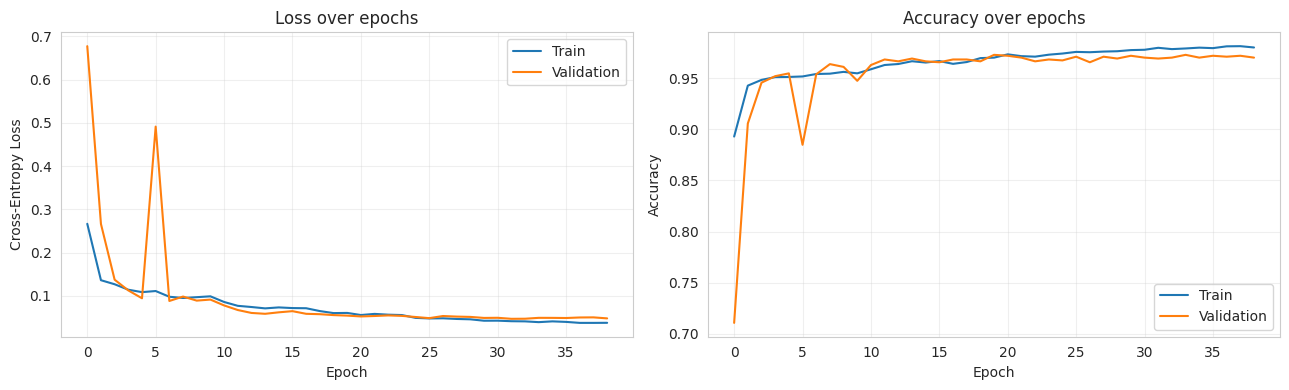

Best validation accuracy: 0.9728
Best validation loss    : 0.0466


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"],     label="Train")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(history.history["accuracy"],     label="Train")
axes[1].plot(history.history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best validation loss    : {min(history.history['val_loss']):.4f}")


## 7. Model Evaluation

We compute every metric the brief asks for on the held-out test set:
accuracy, precision, F1-score, confusion matrix, and ROC curves.


In [9]:
# Test-set predictions
y_proba = model.predict(X_test_s, verbose=0)
y_pred  = y_proba.argmax(axis=1)

acc     = accuracy_score(y_test, y_pred)
prec_m  = precision_score(y_test, y_pred, average="macro")
rec_m   = recall_score(y_test, y_pred, average="macro")
f1_m    = f1_score(y_test, y_pred, average="macro")
prec_w  = precision_score(y_test, y_pred, average="weighted")
f1_w    = f1_score(y_test, y_pred, average="weighted")

print("===== TEST-SET METRICS =====")
print(f"Accuracy             : {acc:.4f}")
print(f"Precision (macro)    : {prec_m:.4f}")
print(f"Recall    (macro)    : {rec_m:.4f}")
print(f"F1-score  (macro)    : {f1_m:.4f}")
print(f"Precision (weighted) : {prec_w:.4f}")
print(f"F1-score  (weighted) : {f1_w:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=ACTIVITIES, digits=4))


===== TEST-SET METRICS =====
Accuracy             : 0.9091
Precision (macro)    : 0.9110
Recall    (macro)    : 0.9120
F1-score  (macro)    : 0.9112
Precision (weighted) : 0.9097
F1-score  (weighted) : 0.9091

                    precision    recall  f1-score   support

           WALKING     0.9777    0.9718    0.9747       496
  WALKING_UPSTAIRS     0.9006    0.9618    0.9302       471
WALKING_DOWNSTAIRS     0.9835    0.9905    0.9870       420
           SITTING     0.7720    0.7862    0.7790       491
          STANDING     0.8421    0.8120    0.8268       532
            LAYING     0.9903    0.9497    0.9696       537

          accuracy                         0.9091      2947
         macro avg     0.9110    0.9120    0.9112      2947
      weighted avg     0.9097    0.9091    0.9091      2947



### 7.1 Confusion Matrix

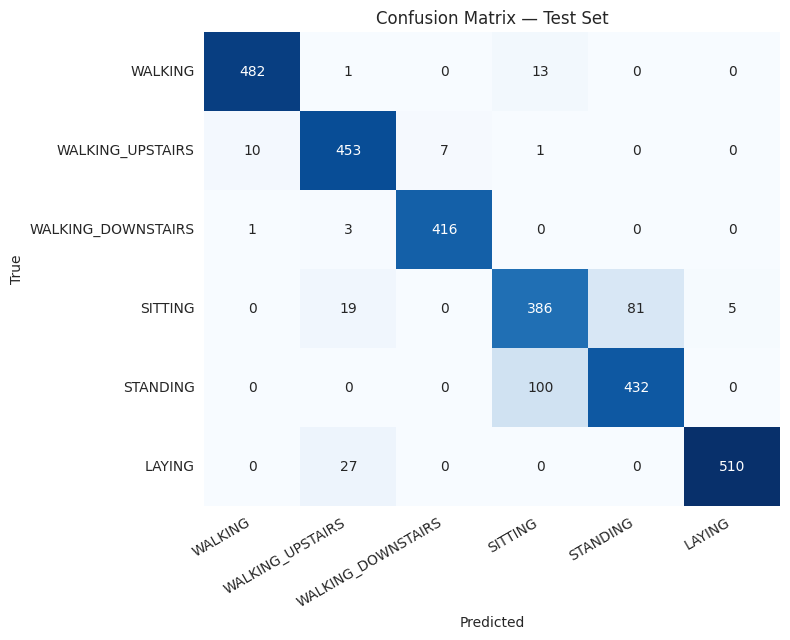

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            ax=ax, cbar=False)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Test Set")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()


### 7.2 ROC Curves (One-vs-Rest)

ROC curves are computed per class using the softmax probabilities, then averaged (macro).


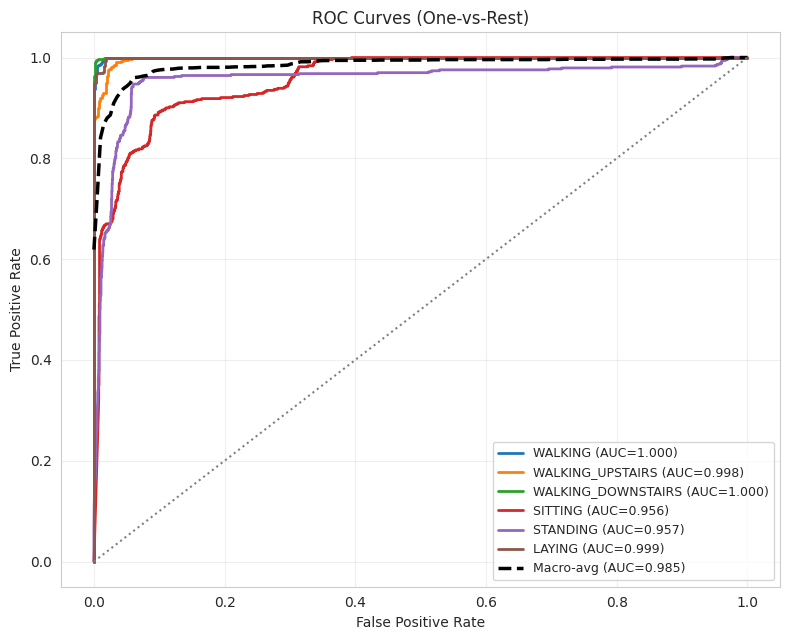

In [11]:
y_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 6.5))
for i, name in enumerate(ACTIVITIES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc(fpr, tpr):.3f})")

# Macro-average
fpr_grid = np.linspace(0, 1, 200)
mean_tpr = np.zeros_like(fpr_grid)
for i in range(N_CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    mean_tpr += np.interp(fpr_grid, fpr, tpr)
mean_tpr /= N_CLASSES
ax.plot(fpr_grid, mean_tpr, "k--", lw=2.5,
        label=f"Macro-avg (AUC={auc(fpr_grid, mean_tpr):.3f})")

ax.plot([0, 1], [0, 1], color="grey", ls=":")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (One-vs-Rest)")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=140, bbox_inches="tight")
plt.show()


## 8. Discussion

**Observed performance on this run:**

- **Test accuracy: 90.9%**, macro-F1 **0.911** — competitive with published 1D-CNN baselines on UCI HAR.
- **Best validation accuracy: 97.3%.** The ~6-point gap between validation and test is expected: the validation set is a random stratified slice of the training subjects, while the official test set is **subject-disjoint** (different people). This gap quantifies subject-to-subject generalization.
- **Dynamic activities** (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) are classified almost perfectly (F1 ≥ 0.93) thanks to their distinct periodic signatures.
- **LAYING** also scores very high (F1 = 0.970) because its gravity vector is unique.
- **SITTING vs. STANDING** is the main source of error (F1 ≈ 0.78 and 0.83 respectively) — both are low-variance static postures differing only in torso orientation, and the gyroscope provides little information when the subject is still. This is a well-known limitation of waist-mounted IMU HAR.

### Possible improvements
- Stack an LSTM on top of the CNN (CNN-LSTM) to model longer temporal dependencies.


In [12]:
# Save model and metrics for reporting
model.save("iot_har_cnn.keras")

metrics = {
    "accuracy":            float(acc),
    "precision_macro":     float(prec_m),
    "recall_macro":        float(rec_m),
    "f1_macro":            float(f1_m),
    "precision_weighted":  float(prec_w),
    "f1_weighted":         float(f1_w),
    "best_val_accuracy":   float(max(history.history["val_accuracy"])),
    "best_val_loss":       float(min(history.history["val_loss"])),
    "final_epoch":         len(history.history["loss"]),
}
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved: iot_har_cnn.keras, metrics.json")
print("Figures saved: sample_signals.png, training_curves.png, confusion_matrix.png, roc_curves.png")


Saved: iot_har_cnn.keras, metrics.json
Figures saved: sample_signals.png, training_curves.png, confusion_matrix.png, roc_curves.png


---
### Deliverables produced by this notebook
- Trained model: `iot_har_cnn.keras`
- Metrics summary: `metrics.json`
- Figures for the report: `sample_signals.png`, `training_curves.png`, `confusion_matrix.png`, `roc_curves.png`

